In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score

In [2]:
df = pd.read_csv("../data/car_data.csv")
df.shape
df.info()
df.describe(include="object")

<class 'pandas.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   name                8128 non-null   str    
 1   year                8128 non-null   int64  
 2   selling_price       8128 non-null   int64  
 3   km_driven           8128 non-null   int64  
 4   fuel                8128 non-null   str    
 5   seller_type         8128 non-null   str    
 6   transmission        8128 non-null   str    
 7   owner               8128 non-null   str    
 8   mileage(km/ltr/kg)  7907 non-null   float64
 9   engine              7907 non-null   float64
 10  max_power           7913 non-null   str    
 11  seats               7907 non-null   float64
dtypes: float64(3), int64(3), str(6)
memory usage: 762.1 KB


C:\Users\Алиса\AppData\Local\Temp\ipykernel_25940\2024744290.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,name,fuel,seller_type,transmission,owner,max_power
count,8128,8128,8128,8128,8128,7913
unique,2058,4,3,2,5,320
top,Maruti Swift Dzire VDI,Diesel,Individual,Manual,First Owner,74
freq,129,4402,6766,7078,5289,377


In [3]:
pd.to_numeric(df["max_power"], errors="coerce").isna().sum()

np.int64(216)

In [4]:
df_clean = df.copy()

df_clean["max_power"] = pd.to_numeric(
    df_clean["max_power"],
    errors="coerce"
)

df_clean.isna().sum()



name                    0
year                    0
selling_price           0
km_driven               0
fuel                    0
seller_type             0
transmission            0
owner                   0
mileage(km/ltr/kg)    221
engine                221
max_power             216
seats                 221
dtype: int64

In [5]:
df_clean = df_clean.drop_duplicates()

In [6]:
df_clean.shape

(6926, 12)

In [7]:
df_clean.duplicated().sum()

np.int64(0)

In [8]:
df_clean = df_clean.dropna(
    subset=["mileage(km/ltr/kg)", "engine", "max_power", "seats"]
)

In [9]:
df_clean.isna().sum()

name                  0
year                  0
selling_price         0
km_driven             0
fuel                  0
seller_type           0
transmission          0
owner                 0
mileage(km/ltr/kg)    0
engine                0
max_power             0
seats                 0
dtype: int64

In [10]:
df_clean.shape

(6717, 12)

In [11]:
df_clean.to_csv("../data/cars_clean.csv", index=False)

In [12]:
df_clean.describe()

,year,selling_price,km_driven,mileage(km/ltr/kg),engine,max_power,seats
count,6717.000000,6.717000e+03,6.717000e+03,6717.000000,6717.000000,6717.000000,6717.000000
mean,2013.611136,5.263860e+05,7.339834e+04,19.466585,1430.985857,87.766100,5.434271
std,3.897402,5.235504e+05,5.870328e+04,4.048102,493.469198,31.724555,0.983805
min,1994.000000,2.999900e+04,1.000000e+00,0.000000,624.000000,32.800000,2.000000
25%,2011.000000,2.500000e+05,3.800000e+04,16.800000,1197.000000,67.100000,5.000000
50%,2014.000000,4.200000e+05,6.820300e+04,19.440000,1248.000000,81.830000,5.000000
75%,2017.000000,6.500000e+05,1.000000e+05,22.500000,1498.000000,100.000000,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,42.000000,3604.000000,400.000000,14.000000


In [13]:
df_clean.sort_values(by="selling_price", ascending=False).head(10)

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats
170,Volvo XC90 T8 Excellence BSIV,2017,10000000,30000,Petrol,Individual,Automatic,First Owner,42.00,1969.0,400.00,4.0
2938,BMW X7 xDrive 30d DPE,2020,7200000,5000,Diesel,Individual,Automatic,First Owner,13.38,2993.0,265.00,7.0
4952,Audi A6 35 TFSI Matrix,2019,6523000,23600,Petrol,Dealer,Automatic,Test Drive Car,15.26,1798.0,187.74,5.0
4950,Audi A6 35 TFSI Matrix,2019,6223000,7800,Petrol,Dealer,Automatic,Test Drive Car,15.26,1798.0,187.74,5.0
1071,BMW 6 Series GT 630d Luxury Line,2018,6000000,28156,Diesel,Dealer,Automatic,First Owner,17.09,2993.0,261.40,4.0
4766,BMW 6 Series GT 630d Luxury Line,2018,6000000,27000,Diesel,Dealer,Automatic,First Owner,17.09,2993.0,261.40,4.0
136,Mercedes-Benz S-Class S 350 CDI,2017,6000000,37000,Diesel,Dealer,Automatic,First Owner,13.50,2987.0,254.79,5.0
4951,Audi A6 35 TFSI Matrix,2019,5923000,11500,Petrol,Dealer,Automatic,Test Drive Car,15.26,1798.0,187.74,5.0
148,Mercedes-Benz S-Class S 350 CDI,2017,5850000,47000,Diesel,Dealer,Automatic,First Owner,13.50,2987.0,282.00,5.0
6258,BMW 6 Series GT 630d Luxury Line,2018,5830000,30000,Diesel,Individual,Automatic,First Owner,17.09,2993.0,261.40,4.0


In [14]:
df_clean[df_clean["km_driven"] > 193000]

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats
287,Mahindra Bolero DI DX 7 Seater,2007,210000,207890,Diesel,Individual,Manual,Second Owner,13.60,2523.0,63.00,7.0
394,Toyota Innova 2.5 G1 Diesel 8-seater,2005,250000,240000,Diesel,Individual,Manual,Third Owner,12.80,2494.0,102.00,8.0
396,Hyundai Verna XXi ABS (Petrol),2009,340000,214000,Petrol,Individual,Manual,Second Owner,13.90,1599.0,103.20,5.0
397,Hyundai Verna CRDi SX,2009,340000,214000,Diesel,Individual,Manual,Second Owner,16.80,1493.0,110.00,5.0
401,Tata Indigo LS,2012,95000,265000,Diesel,Individual,Manual,Second Owner,17.00,1405.0,70.00,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...
8031,Chevrolet Enjoy TCDi LT 7 Seater,2014,275000,195000,Diesel,Individual,Manual,First Owner,18.20,1248.0,73.80,7.0
8033,Hyundai Verna 1.6 SX,2012,450000,200000,Diesel,Individual,Manual,Second Owner,22.32,1582.0,126.32,5.0
8071,Toyota Innova 2.5 V Diesel 7-seater,2010,425000,200000,Diesel,Individual,Manual,Second Owner,12.80,2494.0,102.00,7.0
8077,Toyota Innova 2.5 E 7 STR,2009,550000,250000,Diesel,Individual,Manual,First Owner,12.80,2494.0,102.00,7.0


In [15]:
df_clean.select_dtypes(include="number")

,year,selling_price,km_driven,mileage(km/ltr/kg),engine,max_power,seats
0,2014,450000,145500,23.40,1248.0,74.00,5.0
1,2014,370000,120000,21.14,1498.0,103.52,5.0
2,2006,158000,140000,17.70,1497.0,78.00,5.0
3,2010,225000,127000,23.00,1396.0,90.00,5.0
4,2007,130000,120000,16.10,1298.0,88.20,5.0
...,...,...,...,...,...,...,...
8121,2013,260000,50000,18.90,998.0,67.10,5.0
8122,2014,475000,80000,22.54,1396.0,88.73,5.0
8123,2013,320000,110000,18.50,1197.0,82.85,5.0
8124,2007,135000,119000,16.80,1493.0,110.00,5.0


In [16]:
df_clean.select_dtypes(include="number").corr()

,year,selling_price,km_driven,mileage(km/ltr/kg),engine,max_power,seats
year,1.000000,0.427335,-0.387918,0.366048,-0.019763,0.159889,0.025021
selling_price,0.427335,1.000000,-0.161265,-0.108655,0.442772,0.692323,0.158531
km_driven,-0.387918,-0.161265,1.000000,-0.196419,0.253460,0.041770,0.207890
mileage(km/ltr/kg),0.366048,-0.108655,-0.196419,1.000000,-0.579153,-0.378609,-0.459188
engine,-0.019763,0.442772,0.253460,-0.579153,1.000000,0.683506,0.658711
max_power,0.159889,0.692323,0.041770,-0.378609,0.683506,1.000000,0.259028
seats,0.025021,0.158531,0.207890,-0.459188,0.658711,0.259028,1.000000


In [17]:
y = df_clean["selling_price"]
y.head()

0    450000
1    370000
2    158000
3    225000
4    130000
Name: selling_price, dtype: int64

In [18]:
x = df_clean.drop(columns=["selling_price", "name"])
x.shape

(6717, 10)

In [19]:
from sklearn.model_selection import train_test_split

In [20]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [21]:
x_train.shape

(5373, 10)

In [22]:
x_test.shape

(1344, 10)

In [23]:
categorical_cols = ["fuel", "seller_type", "transmission", "owner"]

In [24]:
encoder = OneHotEncoder(handle_unknown="ignore")

In [25]:
encoder.fit(x_train[categorical_cols])

,"handle_unknown handle_unknown: {'error', 'ignore', 'infrequent_if_exist', 'warn'}, default='error'Specifies the way unknown categories are handled during :meth:`transform`.- 'error' : Raise an error if an unknown category is present during transform.- 'ignore' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will be all zeros. In the inverse transform, an unknown category will be denoted as None.- 'infrequent_if_exist' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will map to the infrequent category if it exists. The infrequent category will be mapped to the last position in the encoding. During inverse transform, an unknown category will be mapped to the category denoted `'infrequent'` if it exists. If the `'infrequent'` category does not exist, then :meth:`transform` and :meth:`inverse_transform` will handle an unknown category as with `handle_unknown='ignore'`. Infrequent categories exist based on `min_frequency` and `max_categories`. Read more in the :ref:`User Guide <encoder_infrequent_categories>`.- 'warn' : When an unknown category is encountered during transform a warning is issued, and the encoding then proceeds as described for `handle_unknown=""infrequent_if_exist""`... versionchanged:: 1.1 `'infrequent_if_exist'` was added to automatically handle unknown categories and infrequent categories... versionadded:: 1.6 The option `""warn""` was added in 1.6.",'ignore'
,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values within a single feature, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute... versionadded:: 0.20",'auto'
,"drop drop: {'first', 'if_binary'} or an array-like of shape (n_features,), default=NoneSpecifies a methodology to use to drop one of the categories perfeature. This is useful in situations where perfectly collinearfeatures cause problems, such as when feeding the resulting datainto an unregularized linear regression model.However, dropping one category breaks the symmetry of the originalrepresentation and can therefore induce a bias in downstream models,for instance for penalized linear classification or regression models.- None : retain all features (the default).- 'first' : drop the first category in each feature. If only one category is present, the feature will be dropped entirely.- 'if_binary' : drop the first category in each feature with two categories. Features with 1 or more than 2 categories are left intact.- array : ``drop[i]`` is the category in feature ``X[:, i]`` that should be dropped.When `max_categories` or `min_frequency` is configured to groupinfrequent categories, the dropping behavior is handled after thegrouping... versionadded:: 0.21 The parameter `drop` was added in 0.21... versionchanged:: 0.23 The option `drop='if_binary'` was added in 0.23... versionchanged:: 1.1 Support for dropping infrequent categories.",None
,"sparse_output sparse_output: bool, default=TrueWhen ``True``, it returns a SciPy sparse matrix/arrayin ""Compressed Sparse Row"" (CSR) format... versionadded:: 1.2 `sparse` was renamed to `sparse_output`",True
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.1 Read more in the :ref:`User Guide <encoder_infrequen

In [26]:
encoded_train = encoder.transform(x_train[categorical_cols])
encoded_train.shape

(5373, 14)

In [27]:
encoder.get_feature_names_out(categorical_cols)

array(['fuel_CNG', 'fuel_Diesel', 'fuel_LPG', 'fuel_Petrol',
       'seller_type_Dealer', 'seller_type_Individual',
       'seller_type_Trustmark Dealer', 'transmission_Automatic',
       'transmission_Manual', 'owner_First Owner',
       'owner_Fourth & Above Owner', 'owner_Second Owner',
       'owner_Test Drive Car', 'owner_Third Owner'], dtype=object)

In [28]:
encoded_test = encoder.transform(x_test[categorical_cols])
encoded_test.shape

(1344, 14)

In [29]:
numeric_cols = [
    "year",
    "km_driven",
    "mileage(km/ltr/kg)",
    "engine",
    "max_power",
    "seats"
]

In [30]:
x_train[numeric_cols].shape

(5373, 6)

In [31]:
x_train_final = np.hstack((
    x_train[numeric_cols].values,
    encoded_train.toarray()
))
x_train_final.shape

(5373, 20)

In [32]:
x_test_final = np.hstack((
    x_test[numeric_cols].values,
    encoded_test.toarray()
))
x_test_final.shape

(1344, 20)

In [33]:
x_train_final[:5]


array([[2.0140e+03, 8.0000e+04, 1.9100e+01, 1.1970e+03, 8.2000e+01,
        5.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00,
        0.0000e+00, 1.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00,
        1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
       [2.0170e+03, 3.5000e+04, 2.5830e+01, 1.4980e+03, 9.9000e+01,
        5.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 1.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00,
        1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
       [2.0130e+03, 6.4000e+04, 1.4620e+01, 1.4980e+03, 1.1342e+02,
        5.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00, 0.0000e+00,
        1.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00,
        1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
       [2.0180e+03, 2.5000e+04, 2.8400e+01, 1.2480e+03, 7.4020e+01,
        5.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 1.0000e+00, 0.0000e+00, 0

In [34]:
model = RandomForestRegressor(n_estimators=100,random_state=42)

In [35]:
model.fit(x_train_final, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [36]:
y_pred = model.predict(x_test_final)
y_pred[:10]


array([1640000.        ,  722169.99666667,  279623.32333333,
       3022700.        , 1642850.        ,  114920.        ,
       1018334.62      ,  381649.95      ,  816035.83333333,
        263746.66666667])

In [37]:
y_test[:10]

7039     450000
5031     800000
2807      75000
1834    3200000
4945    1650000
3819     180000
820     1019999
6650     350000
6629     722000
4869     315000
Name: selling_price, dtype: int64

In [38]:
predictions = pd.DataFrame({
    "actual": y_test.values,
    "predicted": y_pred
})

predictions.head(10)

,actual,predicted
0,450000,1.640000e+06
1,800000,7.221700e+05
2,75000,2.796233e+05
3,3200000,3.022700e+06
4,1650000,1.642850e+06
5,180000,1.149200e+05
6,1019999,1.018335e+06
7,350000,3.816500e+05
8,722000,8.160358e+05
9,315000,2.637467e+05


In [39]:
mae = mean_absolute_error(y_test, y_pred)
mae

77301.18561224786

In [40]:
predictions["error"] = predictions["actual"] - predictions["predicted"]

In [41]:
predictions.head(10)

,actual,predicted,error
0,450000,1.640000e+06,-1.190000e+06
1,800000,7.221700e+05,7.783000e+04
2,75000,2.796233e+05,-2.046233e+05
3,3200000,3.022700e+06,1.773000e+05
4,1650000,1.642850e+06,7.150000e+03
5,180000,1.149200e+05,6.508000e+04
6,1019999,1.018335e+06,1.664380e+03
7,350000,3.816500e+05,-3.164995e+04
8,722000,8.160358e+05,-9.403583e+04
9,315000,2.637467e+05,5.125333e+04


In [42]:
predictions["abs_error"] = predictions["error"].abs()

In [43]:
predictions.sort_values(by="abs_error", ascending=False).head(10)

,actual,predicted,error,abs_error
294,2900000,4.140260e+06,-1.240260e+06,1.240260e+06
0,450000,1.640000e+06,-1.190000e+06,1.190000e+06
69,750000,1.824100e+06,-1.074100e+06,1.074100e+06
1092,3100000,2.202580e+06,8.974200e+05,8.974200e+05
233,2950000,2.073800e+06,8.762000e+05,8.762000e+05
917,1700000,8.331400e+05,8.668600e+05,8.668600e+05
422,3200000,2.347900e+06,8.521002e+05,8.521002e+05
426,620000,1.388287e+06,-7.682866e+05,7.682866e+05
73,1450000,2.217300e+06,-7.672999e+05,7.672999e+05
173,2450000,1.761230e+06,6.887701e+05,6.887701e+05


In [44]:
predictions["error_percent"] = (predictions["abs_error"] / predictions["actual"]) * 100

In [45]:
predictions.sort_values(by="error_percent", ascending=False).head(10)

,actual,predicted,error,abs_error,error_percent
2,75000,2.796233e+05,-2.046233e+05,2.046233e+05,272.831098
0,450000,1.640000e+06,-1.190000e+06,1.190000e+06,264.444444
404,83000,2.512199e+05,-1.682199e+05,1.682199e+05,202.674614
124,260000,7.587200e+05,-4.987200e+05,4.987200e+05,191.815381
249,55000,1.486399e+05,-9.363992e+04,9.363992e+04,170.254400
136,250000,6.585883e+05,-4.085883e+05,4.085883e+05,163.435333
980,70000,1.840540e+05,-1.140540e+05,1.140540e+05,162.934286
425,30000,7.542000e+04,-4.542000e+04,4.542000e+04,151.400000
932,120000,2.926598e+05,-1.726598e+05,1.726598e+05,143.883192
69,750000,1.824100e+06,-1.074100e+06,1.074100e+06,143.213333


In [46]:
predictions["actual"].min()

np.int64(29999)

In [47]:
predictions["actual"].max()

np.int64(6000000)

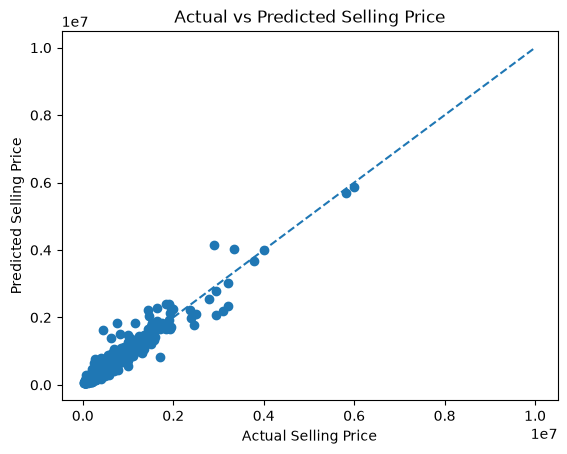

In [48]:
plt.scatter(predictions["actual"], predictions["predicted"])

plt.plot([35000, 10000000],
         [35000, 10000000],
         linestyle="--")

plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Selling Price")

plt.show()

In [49]:
mape = mean_absolute_percentage_error(y_test, y_pred)
mape

0.18759172130876753

In [50]:
r2 = r2_score(y_test, y_pred)
r2

0.919522800394375

In [51]:
model.feature_importances_

array([2.53737794e-01, 4.92249618e-02, 4.21322522e-02, 3.59040353e-02,
       5.91897615e-01, 6.12834700e-03, 1.07547503e-05, 3.21260824e-03,
       1.06408223e-05, 2.72457446e-03, 1.40379229e-03, 1.33373601e-03,
       1.93788683e-05, 3.46198773e-03, 3.87886821e-03, 2.36338197e-03,
       2.03989846e-04, 1.36240020e-03, 4.74489072e-04, 5.14392139e-04])

In [52]:
feature_names = np.concatenate([
    numeric_cols,
    encoder.get_feature_names_out()
])
feature_names

array(['year', 'km_driven', 'mileage(km/ltr/kg)', 'engine', 'max_power',
       'seats', 'fuel_CNG', 'fuel_Diesel', 'fuel_LPG', 'fuel_Petrol',
       'seller_type_Dealer', 'seller_type_Individual',
       'seller_type_Trustmark Dealer', 'transmission_Automatic',
       'transmission_Manual', 'owner_First Owner',
       'owner_Fourth & Above Owner', 'owner_Second Owner',
       'owner_Test Drive Car', 'owner_Third Owner'], dtype=object)

In [53]:
feature_importances = pd.DataFrame({
    "feature": feature_names,
    "importance": model.feature_importances_
})

In [54]:
feature_importances.sort_values(by="importance", ascending=False)

,feature,importance
4,max_power,0.591898
0,year,0.253738
1,km_driven,0.049225
2,mileage(km/ltr/kg),0.042132
3,engine,0.035904
5,seats,0.006128
14,transmission_Manual,0.003879
13,transmission_Automatic,0.003462
7,fuel_Diesel,0.003213
9,fuel_Petrol,0.002725


In [55]:
top_features = feature_importances.sort_values(by="importance", ascending=False).head(10)
top_features

,feature,importance
4,max_power,0.591898
0,year,0.253738
1,km_driven,0.049225
2,mileage(km/ltr/kg),0.042132
3,engine,0.035904
5,seats,0.006128
14,transmission_Manual,0.003879
13,transmission_Automatic,0.003462
7,fuel_Diesel,0.003213
9,fuel_Petrol,0.002725


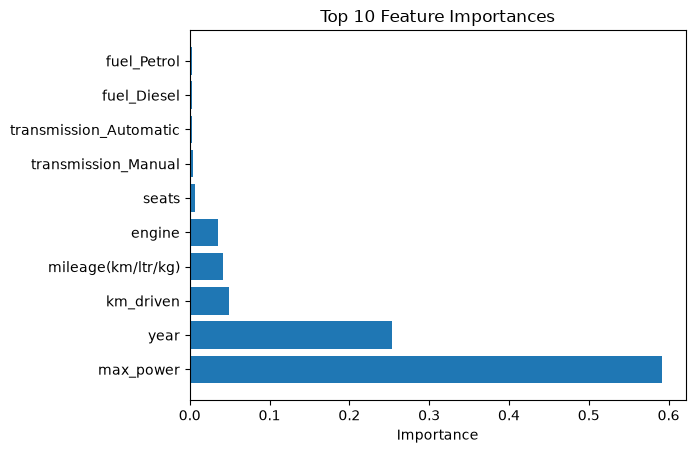

In [56]:
plt.barh(top_features["feature"], top_features["importance"])
plt.xlabel("Importance")
plt.title("Top 10 Feature Importances")
plt.show()

In [57]:
conn = sqlite3.connect(":memory:")

df_clean.to_sql("cars", conn, index=False, if_exists="replace")

print("Таблица cars создана.")


Таблица cars создана.


In [58]:
sql_query_1 = """
SELECT name, selling_price, year, km_driven
FROM cars
ORDER BY selling_price DESC
LIMIT 10;
"""

sql_top_expensive = pd.read_sql_query(sql_query_1, conn)
sql_top_expensive

,name,selling_price,year,km_driven
0,Volvo XC90 T8 Excellence BSIV,10000000,2017,30000
1,BMW X7 xDrive 30d DPE,7200000,2020,5000
2,Audi A6 35 TFSI Matrix,6523000,2019,23600
3,Audi A6 35 TFSI Matrix,6223000,2019,7800
4,Mercedes-Benz S-Class S 350 CDI,6000000,2017,37000
5,BMW 6 Series GT 630d Luxury Line,6000000,2018,28156
6,BMW 6 Series GT 630d Luxury Line,6000000,2018,27000
7,Audi A6 35 TFSI Matrix,5923000,2019,11500
8,Mercedes-Benz S-Class S 350 CDI,5850000,2017,47000
9,BMW 6 Series GT 630d Luxury Line,5830000,2018,30000


In [59]:
sql_query_2 = """
SELECT fuel,
       COUNT(*) AS car_count,
       ROUND(AVG(selling_price), 2) AS avg_price
FROM cars
GROUP BY fuel
ORDER BY avg_price DESC;
"""

sql_fuel = pd.read_sql_query(sql_query_2, conn)
sql_fuel


,fuel,car_count,avg_price
0,Diesel,3658,647996.11
1,Petrol,2973,384050.78
2,CNG,51,317666.61
3,LPG,35,210885.71


In [60]:
sql_query_3 = """
SELECT transmission,
       COUNT(*) AS car_count,
       ROUND(AVG(selling_price), 2) AS avg_price
FROM cars
GROUP BY transmission
ORDER BY avg_price DESC;
"""

sql_transmission = pd.read_sql_query(sql_query_3, conn)
sql_transmission


,transmission,car_count,avg_price
0,Automatic,575,1322916.50
1,Manual,6142,451816.63


In [61]:
sql_query_4 = """
SELECT seller_type,
       COUNT(*) AS car_count,
       ROUND(AVG(selling_price), 2) AS avg_price
FROM cars
GROUP BY seller_type
ORDER BY avg_price DESC;
"""

sql_seller = pd.read_sql_query(sql_query_4, conn)
sql_seller


,seller_type,car_count,avg_price
0,Dealer,666,936708.66
1,Trustmark Dealer,27,718111.11
2,Individual,6024,480162.31


In [62]:
conn.close()

In [63]:
linear_model = LinearRegression()
linear_model.fit(x_train_final, y_train)

linear_pred = linear_model.predict(x_test_final)

linear_mae = mean_absolute_error(y_test, linear_pred)
linear_mape = mean_absolute_percentage_error(y_test, linear_pred)
linear_r2 = r2_score(y_test, linear_pred)

print("Linear Regression")
print("MAE:", linear_mae)
print("MAPE:", linear_mape)
print("R²:", linear_r2)


Linear Regression
MAE: 168482.96739579248
MAPE: 0.5734962561781585
R²: 0.660499876558028


In [64]:
gradient_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gradient_model.fit(x_train_final, y_train)

gradient_pred = gradient_model.predict(x_test_final)

gradient_mae = mean_absolute_error(y_test, gradient_pred)
gradient_mape = mean_absolute_percentage_error(y_test, gradient_pred)
gradient_r2 = r2_score(y_test, gradient_pred)

print("Gradient Boosting")
print("MAE:", gradient_mae)
print("MAPE:", gradient_mape)
print("R²:", gradient_r2)

Gradient Boosting
MAE: 89484.9624598257
MAPE: 0.22952229614926725
R²: 0.9032119067182967


In [65]:
rf_mae = mean_absolute_error(y_test, y_pred)
rf_mape = mean_absolute_percentage_error(y_test, y_pred)
rf_r2 = r2_score(y_test, y_pred)

results = pd.DataFrame({
    "model": ["Linear Regression", "Random Forest", "Gradient Boosting"],
    "MAE": [linear_mae, rf_mae, gradient_mae],
    "MAPE": [linear_mape, rf_mape, gradient_mape],
    "R2": [linear_r2, rf_r2, gradient_r2]
})

results


,model,MAE,MAPE,R2
0,Linear Regression,168482.967396,0.573496,0.660500
1,Random Forest,77301.185612,0.187592,0.919523
2,Gradient Boosting,89484.962460,0.229522,0.903212


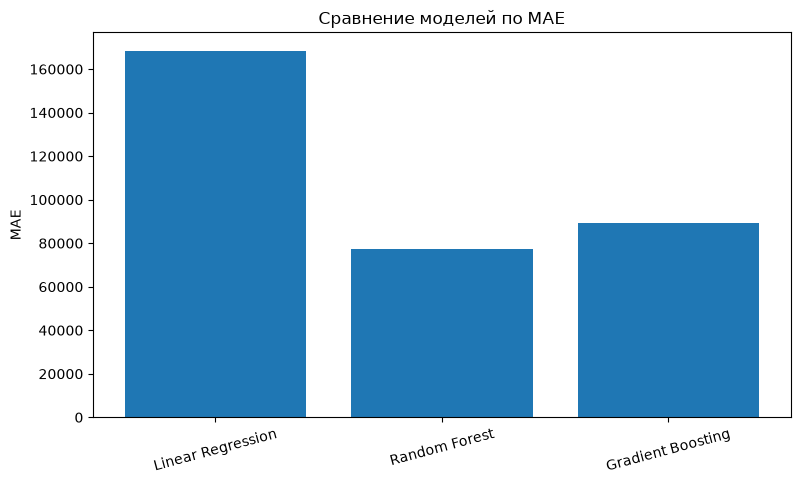

In [66]:
plt.figure(figsize=(9, 5))
plt.bar(results["model"], results["MAE"])
plt.ylabel("MAE")
plt.title("Сравнение моделей по MAE")
plt.xticks(rotation=15)
plt.show()


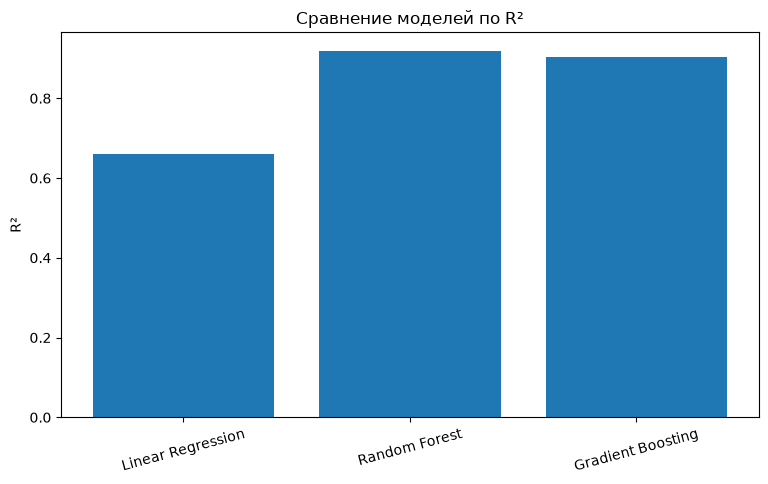

In [67]:
plt.figure(figsize=(9, 5))
plt.bar(results["model"], results["R2"])
plt.ylabel("R²")
plt.title("Сравнение моделей по R²")
plt.xticks(rotation=15)
plt.show()


In [68]:
improved_model = RandomForestRegressor(
    n_estimators=300,
    min_samples_leaf=2,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

improved_model.fit(x_train_final, y_train)

improved_pred = improved_model.predict(x_test_final)

improved_mae = mean_absolute_error(y_test, improved_pred)
improved_mape = mean_absolute_percentage_error(y_test, improved_pred)
improved_r2 = r2_score(y_test, improved_pred)

print("Improved Random Forest")
print("MAE:", improved_mae)
print("MAPE:", improved_mape)
print("R²:", improved_r2)

Improved Random Forest
MAE: 83740.22862108948
MAPE: 0.20742549789673909
R²: 0.9041074688181514


In [69]:
final_results = pd.DataFrame({
    "model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting",
        "Improved Random Forest"
    ],
    "MAE": [
        linear_mae,
        rf_mae,
        gradient_mae,
        improved_mae
    ],
    "MAPE": [
        linear_mape,
        rf_mape,
        gradient_mape,
        improved_mape
    ],
    "R2": [
        linear_r2,
        rf_r2,
        gradient_r2,
        improved_r2
    ]
})

final_results


,model,MAE,MAPE,R2
0,Linear Regression,168482.967396,0.573496,0.660500
1,Random Forest,77301.185612,0.187592,0.919523
2,Gradient Boosting,89484.962460,0.229522,0.903212
3,Improved Random Forest,83740.228621,0.207425,0.904107


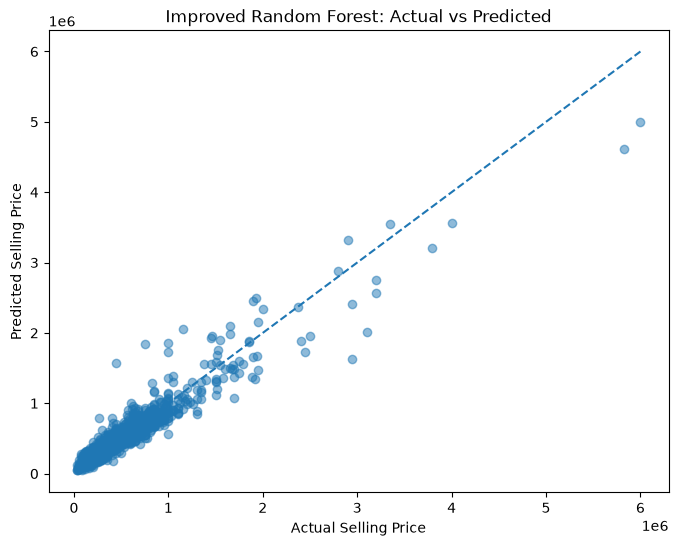

In [70]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, improved_pred, alpha=0.5)

min_price = min(y_test.min(), improved_pred.min())
max_price = max(y_test.max(), improved_pred.max())

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    linestyle="--"
)

plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Improved Random Forest: Actual vs Predicted")
plt.show()


In [71]:
final_predictions = pd.DataFrame({
    "actual": y_test.values,
    "predicted": improved_pred
})

final_predictions["error"] = (
    final_predictions["actual"] - final_predictions["predicted"]
)

final_predictions["abs_error"] = final_predictions["error"].abs()

final_predictions["error_percent"] = (
    final_predictions["abs_error"]
    / final_predictions["actual"]
    * 100
)

final_predictions.head(10)


,actual,predicted,error,abs_error,error_percent
0,450000,1.574534e+06,-1.124534e+06,1.124534e+06,249.896336
1,800000,8.093460e+05,-9.345951e+03,9.345951e+03,1.168244
2,75000,2.459108e+05,-1.709108e+05,1.709108e+05,227.881006
3,3200000,2.571427e+06,6.285731e+05,6.285731e+05,19.642908
4,1650000,1.503250e+06,1.467498e+05,1.467498e+05,8.893927
5,180000,1.504088e+05,2.959124e+04,2.959124e+04,16.439579
6,1019999,8.768587e+05,1.431403e+05,1.431403e+05,14.033377
7,350000,3.663805e+05,-1.638047e+04,1.638047e+04,4.680135
8,722000,7.762595e+05,-5.425948e+04,5.425948e+04,7.515163
9,315000,2.757072e+05,3.929284e+04,3.929284e+04,12.473918


In [72]:
improved_feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": improved_model.feature_importances_
}).sort_values(
    by="importance",
    ascending=False
)

improved_feature_importance


,feature,importance
4,max_power,0.293628
0,year,0.152240
3,engine,0.136277
14,transmission_Manual,0.077606
13,transmission_Automatic,0.073794
1,km_driven,0.071028
2,mileage(km/ltr/kg),0.056655
7,fuel_Diesel,0.024489
5,seats,0.022363
15,owner_First Owner,0.018650


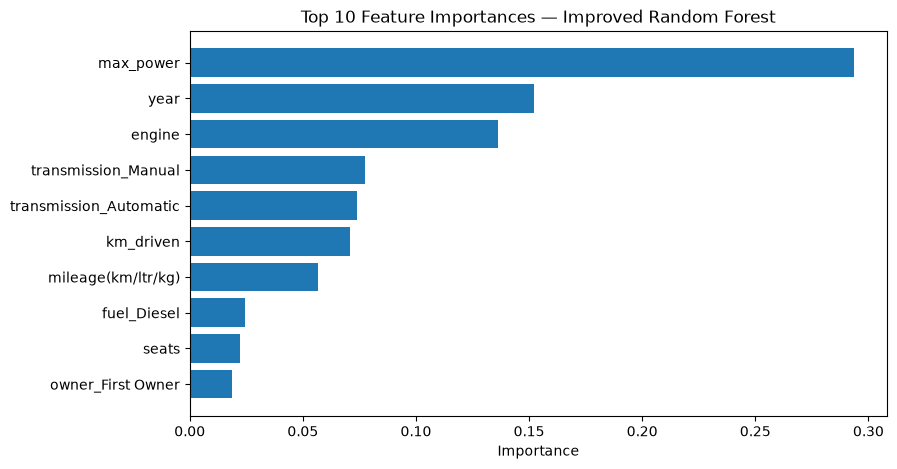

In [73]:
top_improved_features = improved_feature_importance.head(10)

plt.figure(figsize=(9, 5))
plt.barh(
    top_improved_features["feature"][::-1],
    top_improved_features["importance"][::-1]
)
plt.xlabel("Importance")
plt.title("Top 10 Feature Importances — Improved Random Forest")
plt.show()


In [74]:
joblib.dump(model, "../data/car_price_model.pkl", compress=3)
joblib.dump(encoder, "../data/car_price_encoder.pkl")

print("Модель и encoder сохранены.")

Модель и encoder сохранены.


In [75]:
loaded_model = joblib.load("../data/car_price_model.pkl")
loaded_encoder = joblib.load("../data/car_price_encoder.pkl")

loaded_pred = loaded_model.predict(x_test_final)

print("MAE сохранённой модели:",
      mean_absolute_error(y_test, loaded_pred))

print("R² сохранённой модели:",
      r2_score(y_test, loaded_pred))


MAE сохранённой модели: 77301.18561224786
R² сохранённой модели: 0.919522800394375


In [76]:
print("Размер очищенного датасета:", df_clean.shape)
print()
print("Финальная модель: Random Forest (100 деревьев)")
print("MAE:", rf_mae)
print("MAPE:", rf_mape)
print("R²:", rf_r2)

Размер очищенного датасета: (6717, 12)

Финальная модель: Random Forest (100 деревьев)
MAE: 77301.18561224786
MAPE: 0.18759172130876753
R²: 0.919522800394375
